$\textit{That vocabulary's cruel collapse be shunned, and hidden state put to its nobler use}$

- for our paper, we should compute per-model "abs token diversity" on various dataset, so as to perform analysis, and validate the design choice

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from transformers import AutoTokenizer
from sorl.sorl_wrapper import SorlModelWrapper
from sorl.sorl_trainer import get_answer_start_index
from data.pt_dataset import get_dataset

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "Qwen/Qwen3-0.6B"
N_ABS = 32      # abstract vocab size
K     = 8       # abstract tokens per sample

model = SorlModelWrapper.from_pretrained(MODEL_NAME, abstract_vocab_size_list=[N_ABS])
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
model = model.to(device).eval()

bv = int(model.vocab_sizes[0].item())   # base vocab size
d  = model.model.config.hidden_size     # d_model
model_dtype = next(model.parameters()).dtype

ds = get_dataset("gsm8k", split="train", tokenizer=tokenizer, max_length=256)

print(f"Model: {MODEL_NAME} | d={d} | bv={bv} | N_ABS={N_ABS} | K={K}")
print(f"Device: {device} | dtype: {model_dtype}")
print(f"Group size for maxpool: d/N_ABS = {d}/{N_ABS} = {d//N_ABS}")
print(f"Dataset: {len(ds)} samples")

/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model: Qwen/Qwen3-0.6B | d=1024 | bv=151936 | N_ABS=32 | K=8
Device: mps | dtype: torch.bfloat16
Group size for maxpool: d/N_ABS = 1024/32 = 32
Dataset: 7473 samples


## Selection Methods

**Method 1 — v6 Self-Routing** (baseline):
`lm_head(h)[bv:bv+V]` → argmax. Uses learned abstract embeddings.

**Method 2 — Group Max Pool** (zero params):
Consecutive grouping → `max - mean` per group. Raw dims unbalanced → collapse.

**Method 3 — Similar Magnitude CV** (zero params, **key idea**):
Uses `_find_similar_magnitude_dims()` from `sorl.selfroute` — the same helper used by the v6/v7 trainer
when `abs_routing_mode="similar_magnitude"`.

Sort dims by `||lm_head.weight[:bv, j]||₂`, slide a V-wide window, pick the window with **minimal
coefficient of variation** (CV = std / mean). Each abstract token owns exactly 1 hidden dim.
Routing = read V activations, argmax.

In [ ]:
from sorl.selfroute import _find_similar_magnitude_dims


def select_v6_selfroute(h, model, bv, N_ABS):
    """v6 self-routing: logits = lm_head(h)[bv:bv+N_ABS], argmax selection."""
    logits_abs = model.model.lm_head(h)[:, bv:bv+N_ABS]  # (B, N_ABS)
    token_ids = logits_abs.argmax(dim=-1)                  # (B,)
    return token_ids, logits_abs


def select_maxpool(h, N_ABS):
    """Group max pool (consecutive): split h into V groups, score = max - mean."""
    d = h.size(-1)
    h_grouped = h.reshape(-1, N_ABS, d // N_ABS)
    logits = h_grouped.max(dim=-1).values - h_grouped.mean(dim=-1)
    token_ids = logits.argmax(dim=-1)
    return token_ids, logits


def select_similar_magnitude(h, selected_dims):
    """Similar-magnitude routing.
    
    Pick V hidden dims whose lm_head importance magnitudes are most similar.
    Each abstract token owns exactly 1 hidden dim.
    Routing = just read off those V activations, argmax.
    Zero learned params. No grouping. No aggregation. No imbalance.
    """
    logits = h[:, selected_dims]    # (B, V) — one dim per abstract token
    token_ids = logits.argmax(dim=-1)
    return token_ids, logits


# ── Precompute similar-magnitude dims using shared helper ───────────────
with torch.no_grad():
    lm_weight = model.model.lm_head.weight[:bv].float()   # (bv, d)

sim_cv_dims, sim_cv_imp, sim_cv_val = _find_similar_magnitude_dims(lm_weight, N_ABS)
sim_cv_dims = sim_cv_dims.to(device)

print(f"lm_head column importance: min={lm_weight.norm(dim=0).min():.4f}, "
      f"max={lm_weight.norm(dim=0).max():.4f}, mean={lm_weight.norm(dim=0).mean():.4f}")
print(f"\nsimilar_mag_cv (min CV): "
      f"range=[{sim_cv_imp.min():.4f}, {sim_cv_imp.max():.4f}], "
      f"CV={sim_cv_val:.6f}, "
      f"mean={sim_cv_imp.mean():.4f}, std={sim_cv_imp.std():.4f}")

# ── Registry ────────────────────────────────────────────────────────────
METHODS = {
    "v6_selfroute":       lambda h: select_v6_selfroute(h, model, bv, N_ABS),
    "maxpool":            lambda h: select_maxpool(h, N_ABS),
    "similar_mag_cv":     lambda h: select_similar_magnitude(h, sim_cv_dims),
}

print(f"\nRegistered {len(METHODS)} selection methods: {list(METHODS.keys())}")

lm_head column importance: min=8.5000, max=26.0000, mean=11.3073

similar_magnitude (raw spread):  start_idx=269, range=[11.3125, 11.3125], spread=0.0000, mean=11.3125, std=0.0000
similar_mag_cv (min CV):         start_idx=269, range=[11.3125, 11.3125], CV=0.000000, mean=11.3125, std=0.0000
  Full range spread = 17.5000

Registered 4 selection methods: ['v6_selfroute', 'maxpool', 'similar_magnitude', 'similar_mag_cv']


In [3]:
def build_compressed_seq(ids, attn, pl, n_abs, bv, pad_id, answer_token_id=820):
    """Build [query][abs_placeholder × K][answer] compressed sequence."""
    B, L = ids.shape
    ans_start = get_answer_start_index(ids, answer_token_id=answer_token_id)
    valid_len = attn.sum(dim=1)
    ans_len = (valid_len - ans_start).clamp(min=0)
    max_comp_len = int((pl + n_abs + ans_len).max().item())
    comp_data = ids.new_full((B, max_comp_len), pad_id)
    comp_attn = attn.new_zeros(B, max_comp_len)
    placeholder = bv
    for b in range(B):
        p = pl[b].item()
        a = ans_start[b].item()
        al = int(ans_len[b].item())
        comp_data[b, :p] = ids[b, :p]
        comp_attn[b, :p] = 1
        comp_data[b, p:p+n_abs] = placeholder
        comp_attn[b, p:p+n_abs] = 1
        if al > 0:
            comp_data[b, p+n_abs:p+n_abs+al] = ids[b, a:a+al]
            comp_attn[b, p+n_abs:p+n_abs+al] = 1
    return comp_data, comp_attn


def generate_abstract_tokens_autoregressively(
    model, embed_layer, comp_data, comp_attn, bpl, bv, K, N_ABS, methods, device
):
    """
    Autoregressively generate K abstract tokens for each method.
    
    For each abstract token position k (0..K-1):
      1. Build input embeddings from comp_data (using the currently chosen
         abstract token embeddings for positions < k).
      2. Run the model forward to get hidden states.
      3. Extract h at position (prompt_len + k - 1) — the position just
         before the k-th abstract slot.
      4. Apply each selection method to get token_id and logits.
      5. Write the chosen abstract token's embedding into position
         (prompt_len + k) for the next iteration.
    
    Returns:
      seq_tids:   dict[method_name] → list of lists (B × K token ids)
      all_logits:  dict[method_name] → list of tensors (K × (B, N_ABS))
      counters:   dict[method_name] → Counter (accumulated)
    """
    B = comp_data.size(0)
    
    # We maintain per-method copies of input embeddings, since each method
    # may choose different abstract tokens and thus produce different embeddings.
    safe_comp = comp_data.clamp(max=bv - 1)
    base_embeds = embed_layer(safe_comp)  # (B, L_comp, d)
    
    # Per-method state
    method_embeds = {name: base_embeds.clone() for name in methods}
    seq_tids = {name: [[] for _ in range(B)] for name in methods}
    method_logits = {name: [] for name in methods}
    method_counters = {name: Counter() for name in methods}
    
    for k in range(K):
        for name, fn in methods.items():
            embeds = method_embeds[name]
            
            # Forward pass through the transformer backbone
            with torch.no_grad():
                out = model.model.model(
                    inputs_embeds=embeds,
                    attention_mask=comp_attn,
                    use_cache=False,
                )
                h_all = out.last_hidden_state  # (B, L_comp, d)
            
            # Position of the hidden state that predicts the k-th abstract token:
            # This is the position just before the k-th abstract placeholder,
            # i.e., prompt_len + k - 1 (for k=0 this is the last query token).
            prev_pos = (bpl + k - 1).clamp(min=0)
            h_prev = h_all[torch.arange(B, device=device), prev_pos]  # (B, d)
            
            # Apply selection function
            tids, lgts = fn(h_prev)
            tids_cpu = tids.cpu().tolist()
            
            method_counters[name].update(tids_cpu)
            method_logits[name].append(lgts.detach().float().cpu())
            for b_idx in range(B):
                seq_tids[name][b_idx].append(tids_cpu[b_idx])
            
            # Write the chosen abstract token's embedding back into the
            # input for the next iteration.
            # The k-th abstract token sits at position (prompt_len + k).
            abs_pos = bpl + k  # (B,)
            for b_idx in range(B):
                chosen_id = tids_cpu[b_idx]
                # The abstract token embedding is at index (bv + chosen_id)
                abs_embed = embed_layer(
                    torch.tensor([bv + chosen_id], device=device)
                )  # (1, d)
                method_embeds[name][b_idx, abs_pos[b_idx].item()] = abs_embed.squeeze(0)
    
    return seq_tids, method_logits, method_counters


# ── Collect statistics ──────────────────────────────────────────────────
N_BATCHES = 60
BATCH_SZ  = 8

# Global counters (across all samples & positions)
counters   = {name: Counter() for name in METHODS}
# Per-sequence token lists: method → list of lists, each inner list has K token_ids
per_seq    = {name: []        for name in METHODS}
# All logits for distribution analysis
all_logits = {name: []        for name in METHODS}

embed_layer = model.model.model.embed_tokens

for b_start in range(0, min(N_BATCHES * BATCH_SZ, len(ds)), BATCH_SZ):
    b_end = min(b_start + BATCH_SZ, len(ds))
    actual_B = b_end - b_start

    bids  = torch.stack([ds[i]["input_ids"]      for i in range(b_start, b_end)]).to(device)
    battn = torch.stack([ds[i]["attention_mask"]  for i in range(b_start, b_end)]).to(device)
    bpl   = torch.tensor([ds[i]["prompt_len"]     for i in range(b_start, b_end)], device=device)

    comp_data, comp_attn = build_compressed_seq(bids, battn, bpl, K, bv, tokenizer.pad_token_id)

    # Autoregressive abstract token generation
    batch_seq_tids, batch_logits, batch_counters = generate_abstract_tokens_autoregressively(
        model, embed_layer, comp_data, comp_attn, bpl, bv, K, N_ABS, METHODS, device
    )

    # Accumulate
    for name in METHODS:
        counters[name].update(batch_counters[name])
        all_logits[name].extend(batch_logits[name])
        per_seq[name].extend(batch_seq_tids[name])

# ── Per-sequence diversity stats ────────────────────────────────────────
max_ent = np.log(N_ABS)
print(f"Collected {len(per_seq[list(METHODS.keys())[0]])} sequences, K={K} abstract tokens each.\n")
print(f"{'Method':<20s} {'Global unique':>14s} {'Global H':>10s} {'Avg seq unique':>16s} {'Avg seq H':>12s}")
print("-" * 75)
for name in METHODS:
    # Global stats
    counter = counters[name]
    total = sum(counter.values())
    n_unique_global = sum(1 for c in counter.values() if c > 0)
    ent_global = -sum((c/total)*np.log(c/total + 1e-9) for c in counter.values())

    # Per-sequence stats
    seq_uniques = []
    seq_entropies = []
    for tids_list in per_seq[name]:
        cnt = Counter(tids_list)
        n_u = len(cnt)
        seq_uniques.append(n_u)
        tot = sum(cnt.values())
        ent = -sum((c/tot)*np.log(c/tot + 1e-9) for c in cnt.values())
        seq_entropies.append(ent)

    avg_unique = np.mean(seq_uniques)
    avg_ent = np.mean(seq_entropies)
    print(f"{name:<20s} {n_unique_global:>5d}/{N_ABS:<2d}     {ent_global:>10.3f} {avg_unique:>11.2f}/{K:<2d}   {avg_ent:>10.3f}")

Collected 480 sequences, K=8 abstract tokens each.

Method                Global unique   Global H   Avg seq unique    Avg seq H
---------------------------------------------------------------------------
v6_selfroute            26/32          1.399        2.11/8         0.431
maxpool                  5/32          0.947        2.21/8         0.553
similar_magnitude       32/32          2.570        4.84/8         1.411
similar_mag_cv          32/32          2.570        4.84/8         1.411


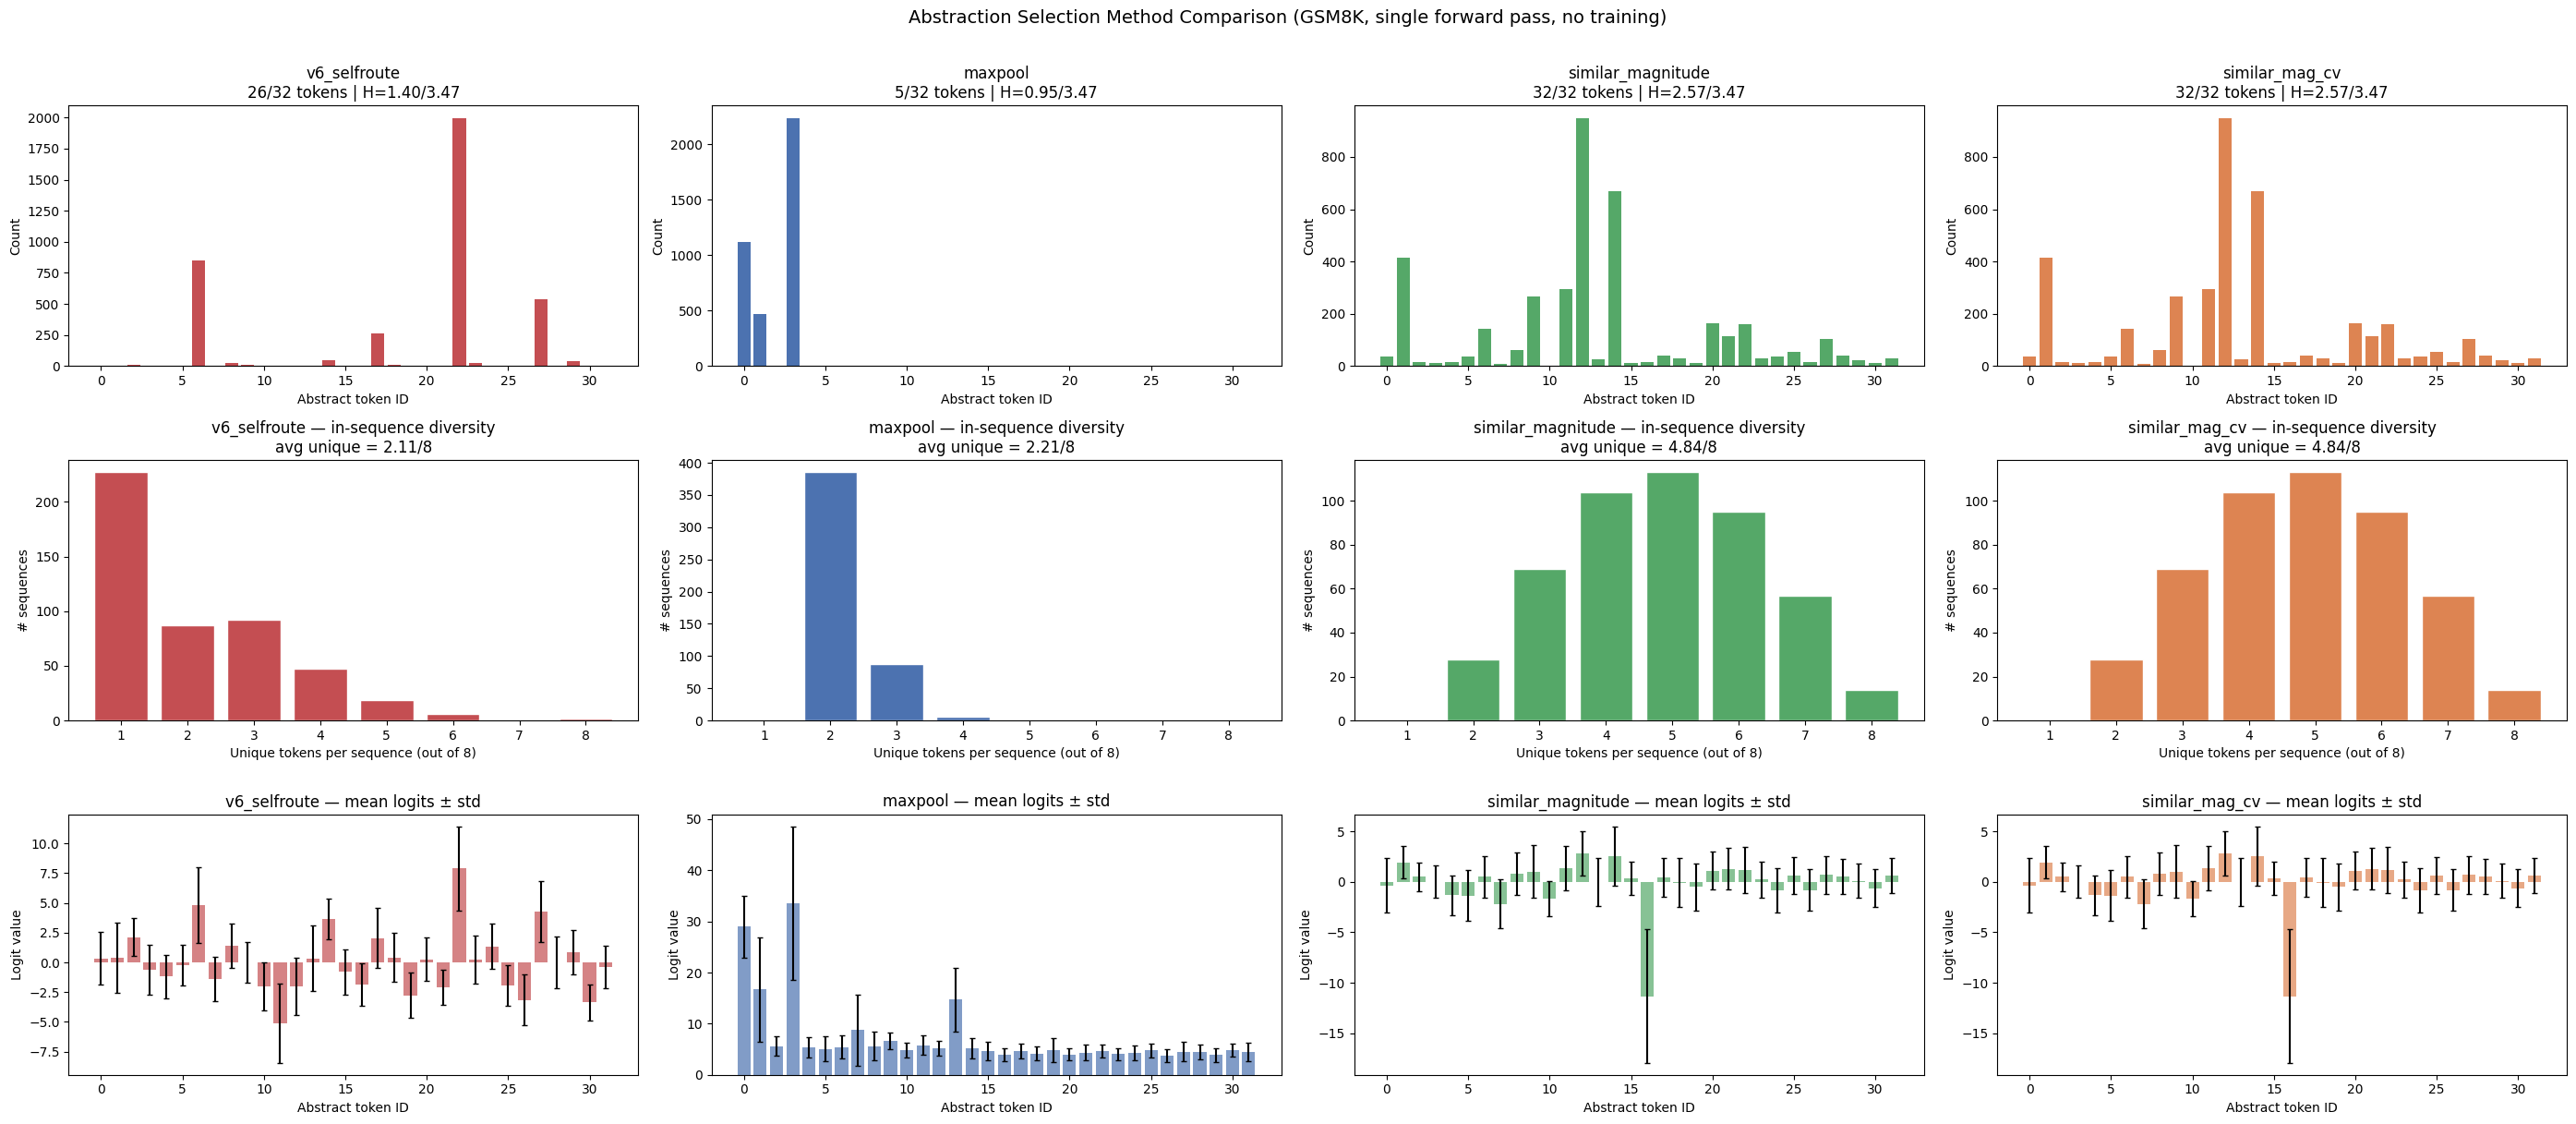

In [4]:
methods = list(METHODS.keys())
n_methods = len(methods)
colors = ["#c44e52", "#4c72b0", "#55a868", "#dd8452"]

fig, axes = plt.subplots(3, n_methods, figsize=(7 * n_methods, 12))
if n_methods == 1:
    axes = axes.reshape(-1, 1)

for col, name in enumerate(methods):
    counter = counters[name]
    counts = [counter.get(i, 0) for i in range(N_ABS)]
    total  = sum(counts)
    n_used = sum(1 for c in counts if c > 0)
    ent    = -sum((c/total)*np.log(c/total + 1e-9) for c in counts if c > 0)
    color  = colors[col % len(colors)]

    # Row 0: global token frequency histogram
    ax = axes[0, col]
    ax.bar(range(N_ABS), counts, color=color)
    ax.set_title(f"{name}\n{n_used}/{N_ABS} tokens | H={ent:.2f}/{max_ent:.2f}", fontsize=12)
    ax.set_xlabel("Abstract token ID")
    ax.set_ylabel("Count")

    # Row 1: per-sequence unique token count distribution
    ax = axes[1, col]
    seq_u = [len(set(tids)) for tids in per_seq[name]]
    ax.hist(seq_u, bins=range(1, K + 2), align="left", color=color, edgecolor="white", rwidth=0.8)
    ax.set_title(f"{name} — in-sequence diversity\navg unique = {np.mean(seq_u):.2f}/{K}", fontsize=12)
    ax.set_xlabel(f"Unique tokens per sequence (out of {K})")
    ax.set_ylabel("# sequences")
    ax.set_xticks(range(1, K + 1))

    # Row 2: mean logits ± std
    ax = axes[2, col]
    stacked = torch.cat(all_logits[name], dim=0).numpy()  # (N_total, N_ABS)
    mean_lgts = stacked.mean(axis=0)
    std_lgts  = stacked.std(axis=0)
    ax.bar(range(N_ABS), mean_lgts, yerr=std_lgts, color=color, alpha=0.7, capsize=2)
    ax.set_title(f"{name} — mean logits ± std", fontsize=12)
    ax.set_xlabel("Abstract token ID")
    ax.set_ylabel("Logit value")

plt.suptitle("Abstraction Selection Method Comparison (GSM8K, single forward pass, no training)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()